# 05 — Cluster Characterization and Method Comparison

This notebook analyzes exported clustering results from the PCA + KMeans + hierarchical clustering step.

It assumes clustering and waveform-feature extraction have already been completed.

Main goals:

1. Load exported cluster assignment and waveform feature CSV files.
2. Merge row-wise waveform features with KMeans and hierarchical cluster labels.
3. Compare KMeans and hierarchical clustering agreement.
4. Summarize waveform features within each cluster.
5. Test whether waveform features differ across clusters.
6. Plot and export cluster-level summaries.
7. Export enriched CSV tables for downstream analysis.


In [1]:
# ==========================
# Imports and settings
# ==========================

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)


plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

output_dir = "../outputs/cluster_characterization"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:")
print(output_dir)


Output directory:
../outputs/cluster_characterization


In [2]:
# ==========================
# File paths
# ==========================

assignments_path = "../outputs/cluster_assignments.csv"
metrics_path = "../outputs/clustering_k_comparison_metrics.csv"
features_path = "../outputs/waveform_features.csv"

kmeans_waveforms_path = "../outputs/spike_waveforms_kmeans_clustered_sorted.csv"
hier_waveforms_path = "../outputs/spike_waveforms_hierarchical_clustered_sorted.csv"


# If running this notebook directly from the uploaded files in the current folder,
# change the paths above to the local filenames, for example:
# assignments_path = "cluster_assignments.csv"
# metrics_path = "clustering_k_comparison_metrics.csv"
# features_path = "waveform_features.csv"
# kmeans_waveforms_path = "spike_waveforms_kmeans_clustered_sorted.csv"
# hier_waveforms_path = "spike_waveforms_hierarchical_clustered_sorted.csv"


In [3]:
# ==========================
# Load exported CSV files
# ==========================

assignments = pd.read_csv(assignments_path)
metrics = pd.read_csv(metrics_path)
features = pd.read_csv(features_path)

kmeans_waveforms = pd.read_csv(kmeans_waveforms_path)
hier_waveforms = pd.read_csv(hier_waveforms_path)

print("assignments:", assignments.shape)
print("metrics:", metrics.shape)
print("features:", features.shape)
print("kmeans_waveforms:", kmeans_waveforms.shape)
print("hier_waveforms:", hier_waveforms.shape)

display(assignments.head())
display(features.head())
display(metrics.head())


assignments: (26862, 3)
metrics: (26, 6)
features: (26862, 10)
kmeans_waveforms: (26862, 64)
hier_waveforms: (26862, 64)


,original_row,kmeans_cluster,hierarchical_cluster
0,0,3,5
1,1,6,3
2,2,6,3
3,3,6,3
4,4,6,3


,baseline_mV,min_mV,max_mV,peak_to_peak_mV,mean_mV,std_mV,time_to_min_ms,time_to_max_ms,dominant_polarity,biphasic
0,13.861667,-140.758333,3392.475,3533.233333,436.162634,830.783209,2.033333,1.033333,positive,True
1,14.436667,-304.643333,382.590,687.233333,25.824409,140.462249,0.900000,1.133333,positive,True
2,-21.075000,-230.988333,299.845,530.833333,35.957366,113.983199,0.866667,1.133333,positive,True
3,-13.931667,-323.471667,260.295,583.766667,11.577796,114.042557,0.900000,1.166667,negative,True
4,5.731667,-366.855000,171.345,538.200000,-16.404462,81.777585,1.033333,1.166667,negative,True


,method,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,2,1.202131e+06,0.909767,7100.281586,0.615767
1,KMeans,3,9.514928e+05,0.868538,8022.685753,0.657292
2,KMeans,4,7.773401e+05,0.807787,8552.189877,0.737717
3,KMeans,5,6.982101e+05,0.605969,7901.750688,0.968496
4,KMeans,6,6.426343e+05,0.609527,7332.338772,1.024655


In [4]:
# ==========================
# Merge waveform features with cluster labels
# ==========================

# waveform_features.csv was created row-wise, but may not include original_row.
# If missing, create original_row from the dataframe index.
if "original_row" not in features.columns:
    features = features.reset_index().rename(
        columns={"index": "original_row"}
    )

cluster_features = features.merge(
    assignments,
    on="original_row",
    how="inner"
)

print("Merged feature table:", cluster_features.shape)

display(cluster_features.head())

cluster_features.to_csv(
    os.path.join(output_dir, "cluster_features_with_assignments.csv"),
    index=False
)


Merged feature table: (26862, 13)


,original_row,baseline_mV,min_mV,max_mV,peak_to_peak_mV,mean_mV,std_mV,time_to_min_ms,time_to_max_ms,dominant_polarity,biphasic,kmeans_cluster,hierarchical_cluster
0,0,13.861667,-140.758333,3392.475,3533.233333,436.162634,830.783209,2.033333,1.033333,positive,True,3,5
1,1,14.436667,-304.643333,382.590,687.233333,25.824409,140.462249,0.900000,1.133333,positive,True,6,3
2,2,-21.075000,-230.988333,299.845,530.833333,35.957366,113.983199,0.866667,1.133333,positive,True,6,3
3,3,-13.931667,-323.471667,260.295,583.766667,11.577796,114.042557,0.900000,1.166667,negative,True,6,3
4,4,5.731667,-366.855000,171.345,538.200000,-16.404462,81.777585,1.033333,1.166667,negative,True,6,3


## Cluster size and KMeans vs hierarchical agreement

The cluster labels from KMeans and hierarchical clustering are not expected to have the same numeric IDs. For example, KMeans cluster 1 may correspond most closely to hierarchical cluster 4. Therefore, agreement should be evaluated using a contingency table and label-invariant metrics such as Adjusted Rand Index and Normalized Mutual Information.


In [5]:
# ==========================
# Cluster sizes and method agreement
# ==========================

kmeans_counts = cluster_features["kmeans_cluster"].value_counts().sort_index()
hier_counts = cluster_features["hierarchical_cluster"].value_counts().sort_index()

display(pd.DataFrame({
    "kmeans_count": kmeans_counts,
    "hierarchical_count": hier_counts
}))

agreement_table = pd.crosstab(
    cluster_features["kmeans_cluster"],
    cluster_features["hierarchical_cluster"]
)

display(agreement_table)

ari = adjusted_rand_score(
    cluster_features["kmeans_cluster"],
    cluster_features["hierarchical_cluster"]
)

nmi = normalized_mutual_info_score(
    cluster_features["kmeans_cluster"],
    cluster_features["hierarchical_cluster"]
)

print("Adjusted Rand Index:", ari)
print("Normalized Mutual Information:", nmi)

agreement_table.to_csv(
    os.path.join(output_dir, "kmeans_vs_hierarchical_crosstab.csv")
)


,kmeans_count,hierarchical_count
1,1056,1744
2,73,91
3,1566,21761
4,193,186
5,164,2855
6,23711,99
7,99,126


hierarchical_cluster,1,2,3,4,5,6,7
kmeans_cluster,,,,,,,
1,974,0,48,15,19,0,0
2,0,73,0,0,0,0,0
3,5,0,42,0,1499,20,0
4,13,4,5,171,0,0,0
5,5,0,0,0,8,25,126
6,747,0,21640,0,1324,0,0
7,0,14,26,0,5,54,0


Adjusted Rand Index: 0.6453579896082509
Normalized Mutual Information: 0.563403295732055


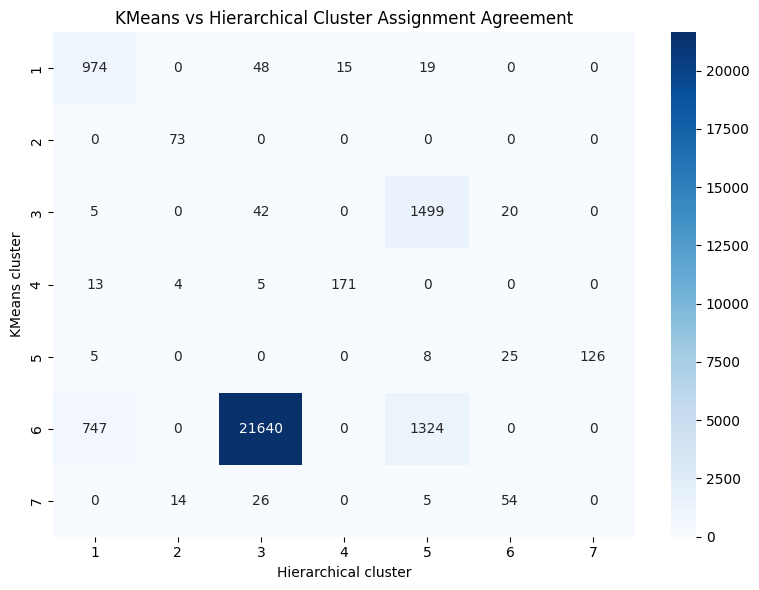

In [6]:
# ==========================
# Plot method agreement heatmap
# ==========================

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    agreement_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax
)

ax.set_xlabel("Hierarchical cluster")
ax.set_ylabel("KMeans cluster")
ax.set_title("KMeans vs Hierarchical Cluster Assignment Agreement")

plt.tight_layout()

fig.savefig(
    os.path.join(output_dir, "kmeans_vs_hierarchical_crosstab.tiff"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Cluster-level feature summaries

The goal here is to describe what each cluster looks like in terms of waveform parameters, such as amplitude, peak-to-peak voltage, baseline, waveform timing, and polarity.


In [7]:
# ==========================
# Numeric and categorical feature columns
# ==========================

numeric_features = [
    col for col in cluster_features.columns
    if col not in [
        "original_row",
        "kmeans_cluster",
        "hierarchical_cluster",
        "dominant_polarity",
        "biphasic"
    ]
    and pd.api.types.is_numeric_dtype(cluster_features[col])
]

categorical_features = [
    col for col in ["dominant_polarity", "biphasic"]
    if col in cluster_features.columns
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['baseline_mV', 'min_mV', 'max_mV', 'peak_to_peak_mV', 'mean_mV', 'std_mV', 'time_to_min_ms', 'time_to_max_ms']

Categorical features:
['dominant_polarity', 'biphasic']


In [9]:
# ==========================
# Feature summaries by cluster
# ==========================

def summarize_by_cluster(data, cluster_col, numeric_cols):
    summary = (
        data
        .groupby(cluster_col)[numeric_cols]
        .agg(["count", "mean", "std", "median", "min", "max"])
    )
    return summary


kmeans_summary = summarize_by_cluster(
    cluster_features,
    "kmeans_cluster",
    numeric_features
)

hier_summary = summarize_by_cluster(
    cluster_features,
    "hierarchical_cluster",
    numeric_features
)

display(kmeans_summary)
display(hier_summary)

kmeans_summary.to_csv(
    os.path.join(output_dir, "kmeans_cluster_feature_summary.csv")
)

hier_summary.to_csv(
    os.path.join(output_dir, "hierarchical_cluster_feature_summary.csv")
)


baseline_mV                                                     \
                     count         mean         std       median          min   
kmeans_cluster                                                                  
1                     1056    47.878005  147.117090    17.110000  -384.726667   
2                       73 -1629.056858  476.977443 -1613.725000 -2868.076667   
3                     1566    12.108727   87.054807     1.480833  -372.813333   
4                      193    30.540762  251.251954    36.671667 -1197.863333   
5                      164     8.392341  296.655496   -35.067500  -638.891667   
6                    23711     0.374721   37.766188     1.303000  -685.991667   
7                       99  -454.034327  252.056144  -444.550000 -1080.738333   

                            min_mV                                         \
                        max  count         mean          std       median   
kmeans_cluster                                                              
1               1360.911667   1056 -3300.403856  1247.759218 -3418.183334   
2               -749.776667     73 -3831.999671  1136.325850 -3720.721667   
3                867.783333   1566  -198.885534   257.684884  -141.158333   
4                958.875000    193 -4371.218693  1068.045474 -4340.108333   
5               2545.583333    164  -188.615171   315.865341   -82.675833   
6                751.163000  23711  -506.084522   525.688132  -359.928333   
7                 91.560000     99 -1153.180818   870.467337  -785.516667   

                                         max_mV                            \
                        min          max  count         mean          std   
kmeans_cluster                                                              
1              -6076.710000  -378.878571   1056   346.932059   491.683358   
2              -6872.443333 -1481.963333     73  2104.725169   924.614831   
3              -3358.440000   -12.280000   1566  3415.997163  1374.335811   
4              -6572.523333 -2108.903000    193   318.936161   409.586619   
5              -2957.256667   -16.135000    164  5349.332146   819.137445   
6              -5800.750000    -6.426000  23711   373.978441   465.034802   
7              -3734.060000  -196.381667     99  3141.213256  1447.188048   

                                                      peak_to_peak_mV  \
                     median          min          max           count   
kmeans_cluster                                                          
1                195.669167    15.005000  4118.125000            1056   
2               1976.516667   690.933333  4638.130000              73   
3               3503.910833   627.358333  6402.503333            1566   
4                166.503333    16.585000  2433.166667             193   
5               5549.521667  2823.063333  6245.781667             164   
6                240.435000     7.480000  5423.633333           23711   
7               3514.443333   549.243333  5899.963333              99   

                                                                    \
                       mean          std       median          min   
kmeans_cluster                                                       
1               3647.335915  1233.022915  3754.366667   562.500000   
2               5936.724840   962.501109  5974.166667  3215.933333   
3               3614.882697  1375.041275  3679.666667   741.266667   
4               4690.154853   957.243397  4638.433333  2288.420000   
5               5537.947317   749.770661  5770.733333  3024.433333   
6                880.062964   753.290164   632.566667    53.673469   
7               4294.394074  1489.039366  4673.866666  1110.133333   

                            mean_mV                                        \
                        max   count         mean         std       median   
kmeans_cluster                                                              

baseline_mV                                        \
                           count         mean         std       median   
hierarchical_cluster                                                     
1                           1744    34.129431  145.996628     8.971667   
2                             91 -1464.940927  547.377792 -1471.724000   
3                          21761    -2.260059   36.396411     0.741667   
4                            186    59.448057  182.892293    49.202500   
5                           2855    24.185158   78.807231    15.101667   
6                             99  -322.203290  246.582661  -247.646667   
7                            126   -27.239558  113.816196   -33.304167   

                                               min_mV               \
                              min          max  count         mean   
hierarchical_cluster                                                 
1                     -320.855000  2545.583333   1744 -2871.962038   
2                    -2868.076667  -538.020000     91 -3717.776780   
3                     -755.023333   195.930000  21761  -469.936037   
4                     -951.463333   556.081667    186 -4362.287441   
5                     -612.433333   972.650000   2855  -214.079133   
6                     -877.793333    91.560000     99  -533.047182   
7                     -305.648333   465.388333    126  -129.203548   

                                                                          \
                              std       median          min          max   
hierarchical_cluster                                                       
1                     1301.193009 -2902.350000 -6076.710000  -126.346667   
2                     1202.937838 -3531.370000 -6872.443333 -1481.963333   
3                      401.050036  -364.046667 -5800.750000    -6.426000   
4                     1082.937463 -4353.083333 -6179.905000 -1862.970000   
5                      298.906163  -136.680000 -4231.553333   -12.280000   
6                      557.625991  -342.455000 -3199.503333   -50.551667   
7                      163.868240   -64.054167 -1062.106667   -16.135000   

                     max_mV                                         \
                      count         mean          std       median   
hierarchical_cluster                                                 
1                      1744   416.102322   570.513322   231.920000   
2                        91  2037.621095  1006.149299  1822.686667   
3                     21761   315.721148   332.829002   229.531667   
4                       186   228.978186   252.145188   146.158167   
5                      2855  2484.590454  1612.089884  2445.880000   
6                        99  3804.577599  1396.708508  4067.248333   
7                       126  5495.413384   729.351868  5798.780833   

                                               peak_to_peak_mV               \
                              min          max           count         mean   
hierarchical_cluster                                                          
1                       12.698333  5397.723333            1744  3288.064360   
2                      413.310000  5104.600000              91  5755.397875   
3                        7.480000  5899.963333           21761   785.657186   
4                       16.585000  2092.546667             186  4591.265627   
5                       67.940000  6402.503333            2855  2698.669587   
6                     1018.170000  6097.368333              99  4337.624781   
7                     3403.301000  6245.781667             126  5624.616931   

                                                                          \
                              std       median          min          max   
hierarchical_cluster                                                       
1                     1278.184205  3317.216667   199.933333  8005.000000   
2                     

In [10]:
# ==========================
# Categorical summaries by cluster
# ==========================

if "dominant_polarity" in cluster_features.columns:

    kmeans_polarity = pd.crosstab(
        cluster_features["kmeans_cluster"],
        cluster_features["dominant_polarity"]
    )

    hier_polarity = pd.crosstab(
        cluster_features["hierarchical_cluster"],
        cluster_features["dominant_polarity"]
    )

    display(kmeans_polarity)
    display(hier_polarity)

    kmeans_polarity.to_csv(
        os.path.join(output_dir, "kmeans_dominant_polarity_counts.csv")
    )

    hier_polarity.to_csv(
        os.path.join(output_dir, "hierarchical_dominant_polarity_counts.csv")
    )


if "biphasic" in cluster_features.columns:

    kmeans_biphasic = pd.crosstab(
        cluster_features["kmeans_cluster"],
        cluster_features["biphasic"]
    )

    hier_biphasic = pd.crosstab(
        cluster_features["hierarchical_cluster"],
        cluster_features["biphasic"]
    )

    display(kmeans_biphasic)
    display(hier_biphasic)

    kmeans_biphasic.to_csv(
        os.path.join(output_dir, "kmeans_biphasic_counts.csv")
    )

    hier_biphasic.to_csv(
        os.path.join(output_dir, "hierarchical_biphasic_counts.csv")
    )


dominant_polarity,negative,positive
kmeans_cluster,,
1,1027,29
2,60,13
3,10,1556
4,193,0
5,0,164
6,18220,5491
7,16,83


dominant_polarity,negative,positive
hierarchical_cluster,,
1,1662,82
2,74,17
3,17509,4252
4,186,0
5,94,2761
6,1,98
7,0,126


biphasic,True
kmeans_cluster,
1,1056
2,73
3,1566
4,193
5,164
6,23711
7,99


biphasic,True
hierarchical_cluster,
1,1744
2,91
3,21761
4,186
5,2855
6,99
7,126


## Statistical comparisons across clusters

For each waveform feature, this notebook runs:

- **One-way ANOVA**: tests whether cluster means differ.
- **Kruskal-Wallis test**: non-parametric test that is less sensitive to non-normal distributions.

With large datasets, p-values can become very small even for modest differences, so also inspect effect sizes visually using boxplots and cluster means.


In [11]:
# ==========================
# Statistical tests across clusters
# ==========================

def test_feature_differences(data, cluster_col, numeric_cols):
    results = []

    clusters = sorted(data[cluster_col].dropna().unique())

    for feature in numeric_cols:

        groups = [
            data.loc[data[cluster_col] == cluster, feature].dropna()
            for cluster in clusters
        ]

        groups = [
            group for group in groups
            if len(group) > 1
        ]

        if len(groups) < 2:
            continue

        anova_stat, anova_p = stats.f_oneway(*groups)
        kruskal_stat, kruskal_p = stats.kruskal(*groups)

        results.append({
            "cluster_method": cluster_col,
            "feature": feature,
            "anova_F": anova_stat,
            "anova_p": anova_p,
            "kruskal_H": kruskal_stat,
            "kruskal_p": kruskal_p
        })

    return pd.DataFrame(results)


kmeans_tests = test_feature_differences(
    cluster_features,
    "kmeans_cluster",
    numeric_features
)

hier_tests = test_feature_differences(
    cluster_features,
    "hierarchical_cluster",
    numeric_features
)

stats_tests = pd.concat(
    [kmeans_tests, hier_tests],
    ignore_index=True
)

display(stats_tests)

stats_tests.to_csv(
    os.path.join(output_dir, "cluster_feature_statistical_tests.csv"),
    index=False
)


,cluster_method,feature,anova_F,anova_p,kruskal_H,kruskal_p
0,kmeans_cluster,baseline_mV,8250.836641,0.000000e+00,853.964948,3.354997e-181
1,kmeans_cluster,min_mV,6015.152507,0.000000e+00,5318.846703,0.000000e+00
2,kmeans_cluster,max_mV,9320.994016,0.000000e+00,5142.663880,0.000000e+00
3,kmeans_cluster,peak_to_peak_mV,6238.734879,0.000000e+00,7313.787920,0.000000e+00
4,kmeans_cluster,mean_mV,18473.249264,0.000000e+00,7920.594965,0.000000e+00
5,kmeans_cluster,std_mV,14630.742937,0.000000e+00,7929.016306,0.000000e+00
6,kmeans_cluster,time_to_min_ms,304.730629,0.000000e+00,1202.026802,1.743331e-256
7,kmeans_cluster,time_to_max_ms,253.120030,4.123291e-316,1507.559087,0.000000e+00
8,hierarchical_cluster,baseline_mV,7550.115194,0.000000e+00,1228.884259,2.682374e-262
9,hierarchical_cluster,min_mV,8404.635311,0.000000e+00,7644.714423,0.000000e+00


## Feature boxplots

These plots show how waveform parameters differ across clusters. This is usually more interpretable than p-values alone.


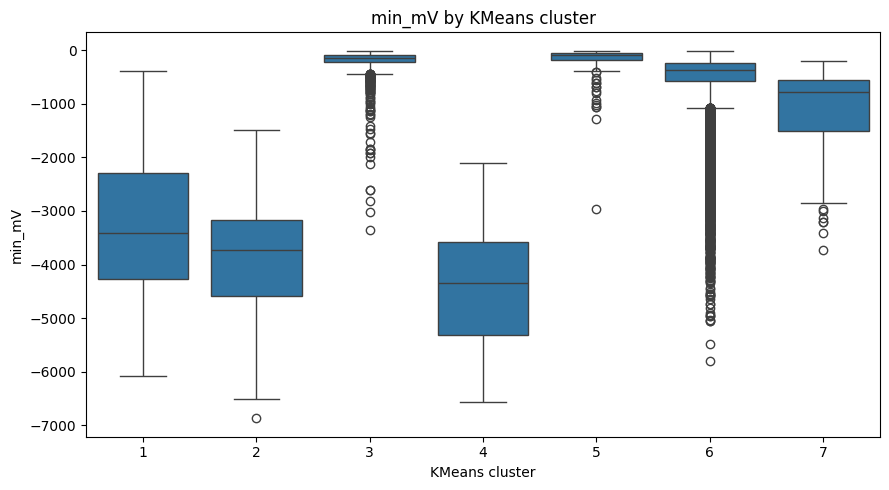

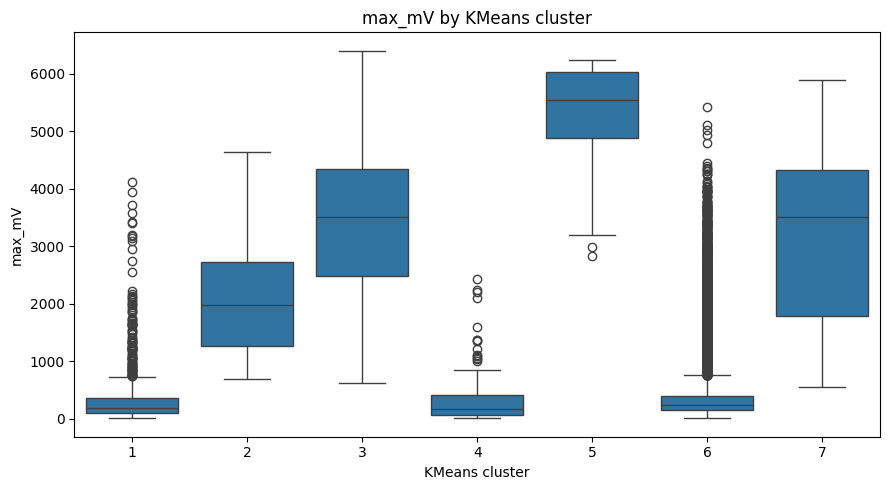

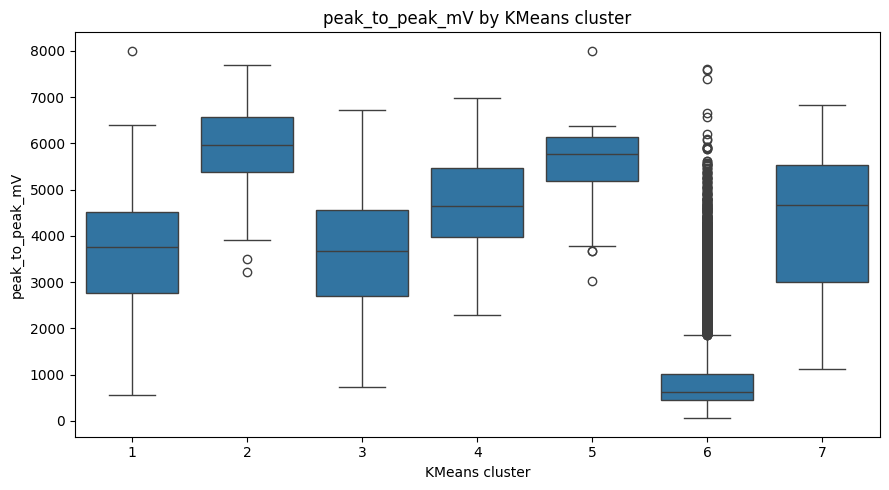

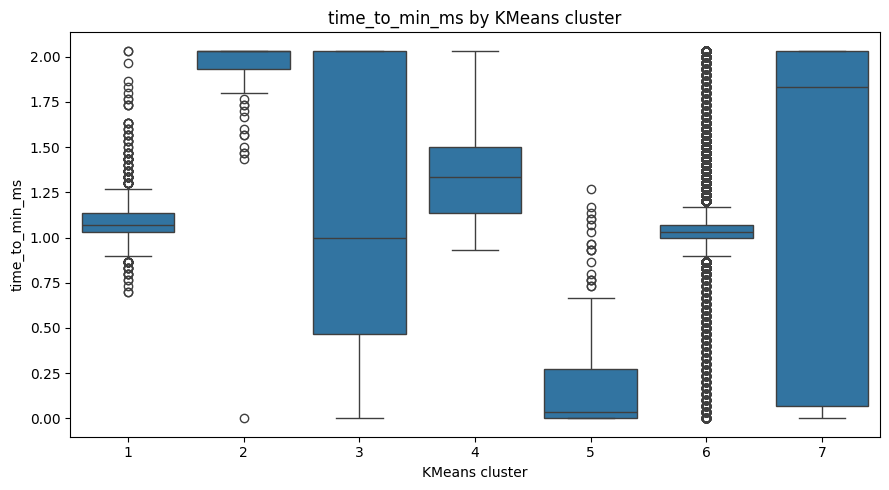

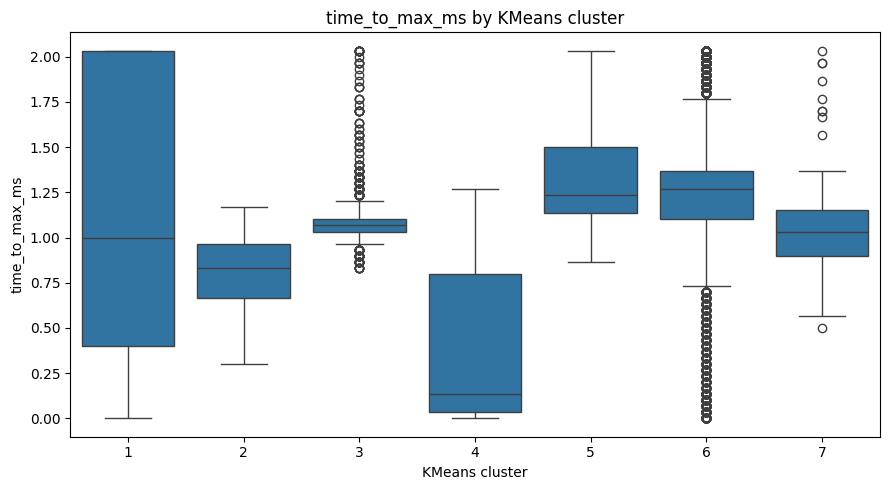

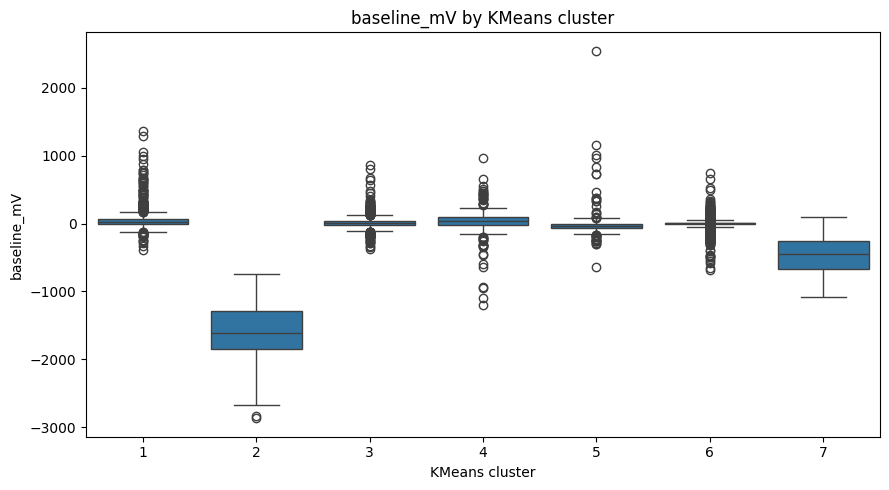

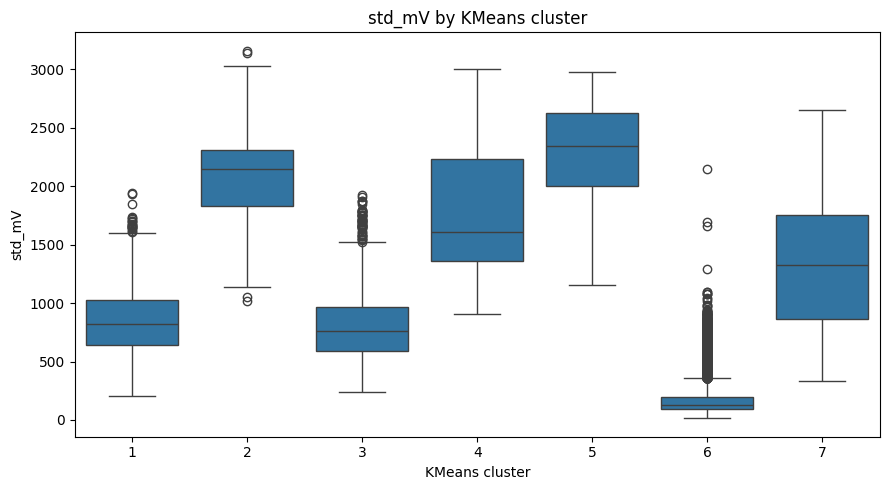

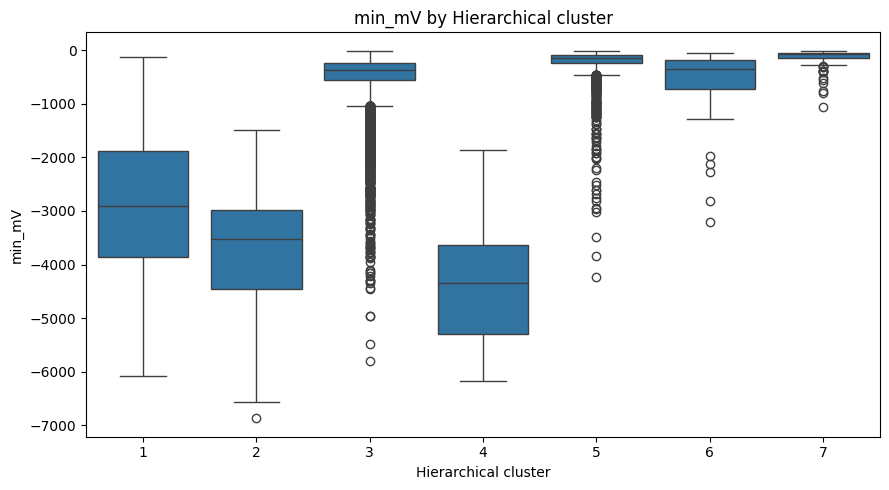

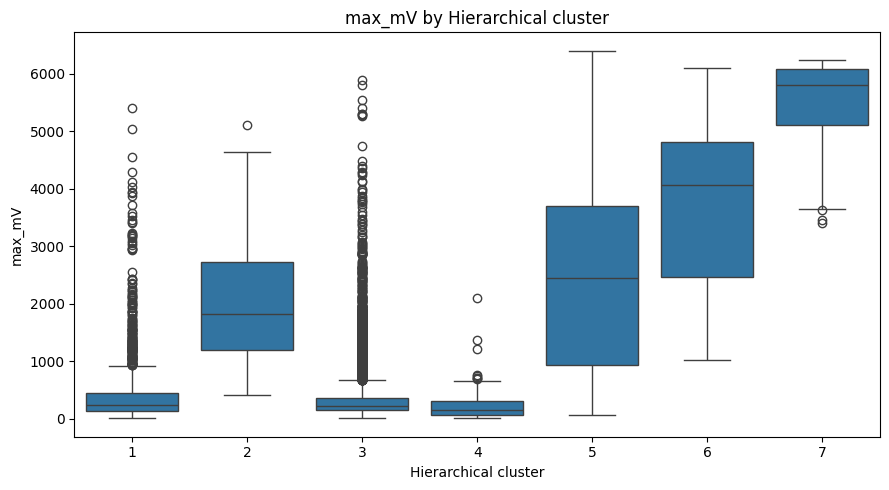

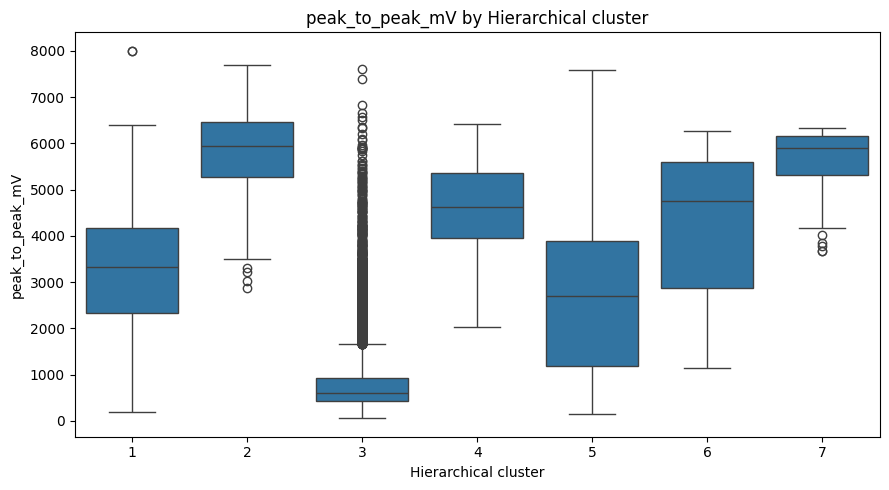

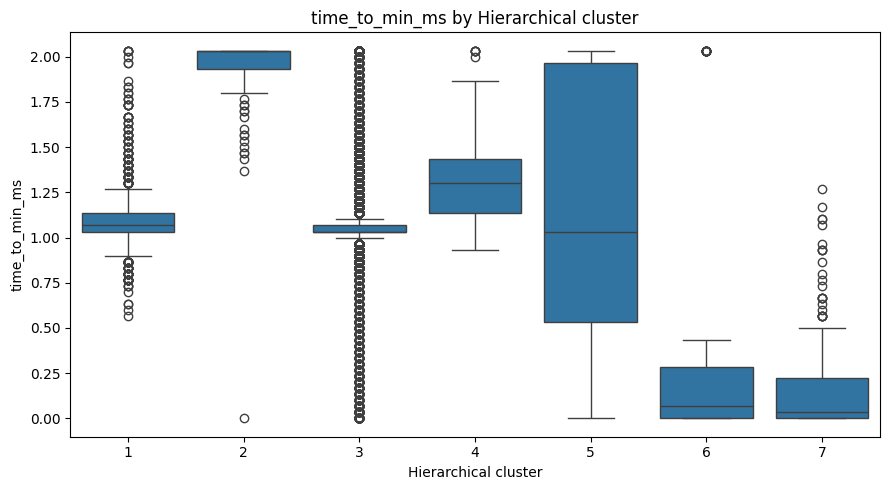

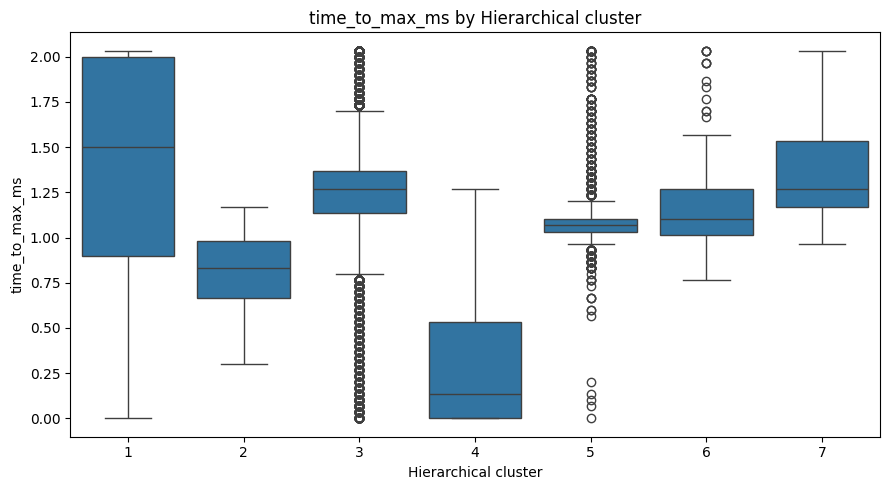

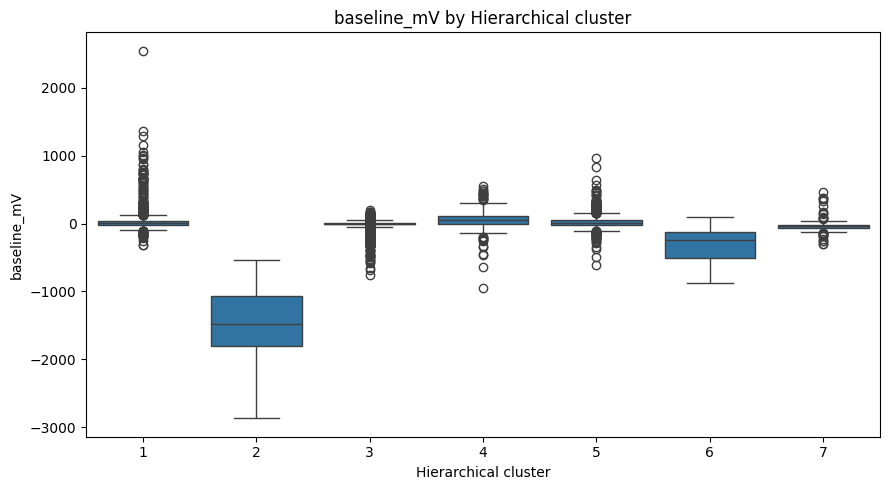

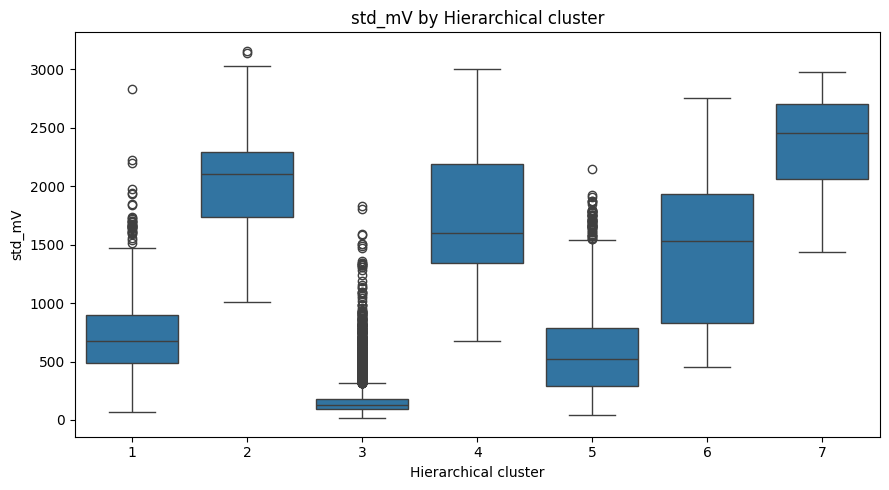

In [12]:
# ==========================
# Boxplots for important features
# ==========================

features_to_plot = [
    feature for feature in [
        "min_mV",
        "max_mV",
        "peak_to_peak_mV",
        "time_to_min_ms",
        "time_to_max_ms",
        "baseline_mV",
        "std_mV"
    ]
    if feature in cluster_features.columns
]


def plot_feature_boxplots(data, cluster_col, features, method_name):
    for feature in features:

        fig, ax = plt.subplots(figsize=(9, 5))

        sns.boxplot(
            data=data,
            x=cluster_col,
            y=feature,
            ax=ax
        )

        ax.set_xlabel(f"{method_name} cluster")
        ax.set_ylabel(feature)
        ax.set_title(f"{feature} by {method_name} cluster")

        plt.tight_layout()

        fig.savefig(
            os.path.join(
                output_dir,
                f"{method_name.lower()}_{feature}_boxplot.tiff"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


plot_feature_boxplots(
    cluster_features,
    "kmeans_cluster",
    features_to_plot,
    "KMeans"
)

plot_feature_boxplots(
    cluster_features,
    "hierarchical_cluster",
    features_to_plot,
    "Hierarchical"
)


## Mean waveform per cluster

These plots show the average raw waveform shape for each cluster. This is one of the most important biological sanity checks because it shows whether the clusters correspond to visibly different response shapes.


In [13]:
# ==========================
# Prepare waveform columns and time axis
# ==========================

sampling_rate_hz = 30000

waveform_cols = [
    col for col in kmeans_waveforms.columns
    if col not in ["kmeans_cluster", "hierarchical_cluster", "original_row"]
]

# Keep only columns that are numeric timepoint names.
waveform_cols = [
    col for col in waveform_cols
    if str(col).isdigit()
]

time_ms = np.arange(len(waveform_cols)) / sampling_rate_hz * 1000

print("Waveform timepoints:", len(waveform_cols))
print("Duration ms:", time_ms[-1])


Waveform timepoints: 62
Duration ms: 2.033333333333333


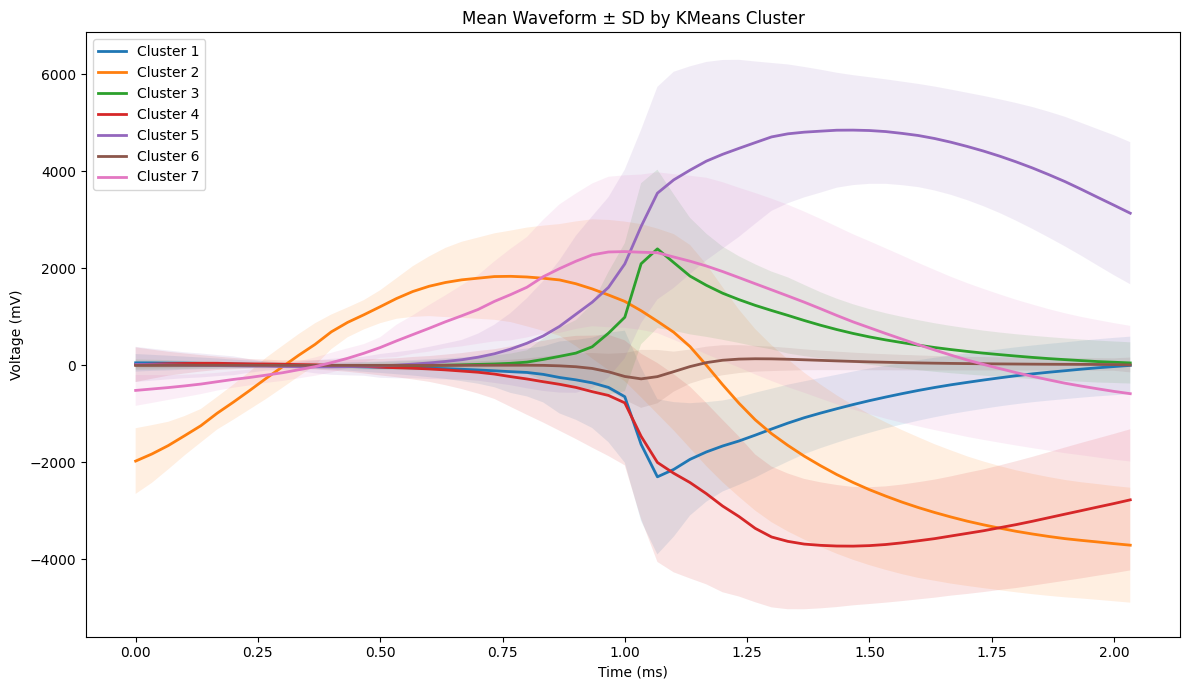

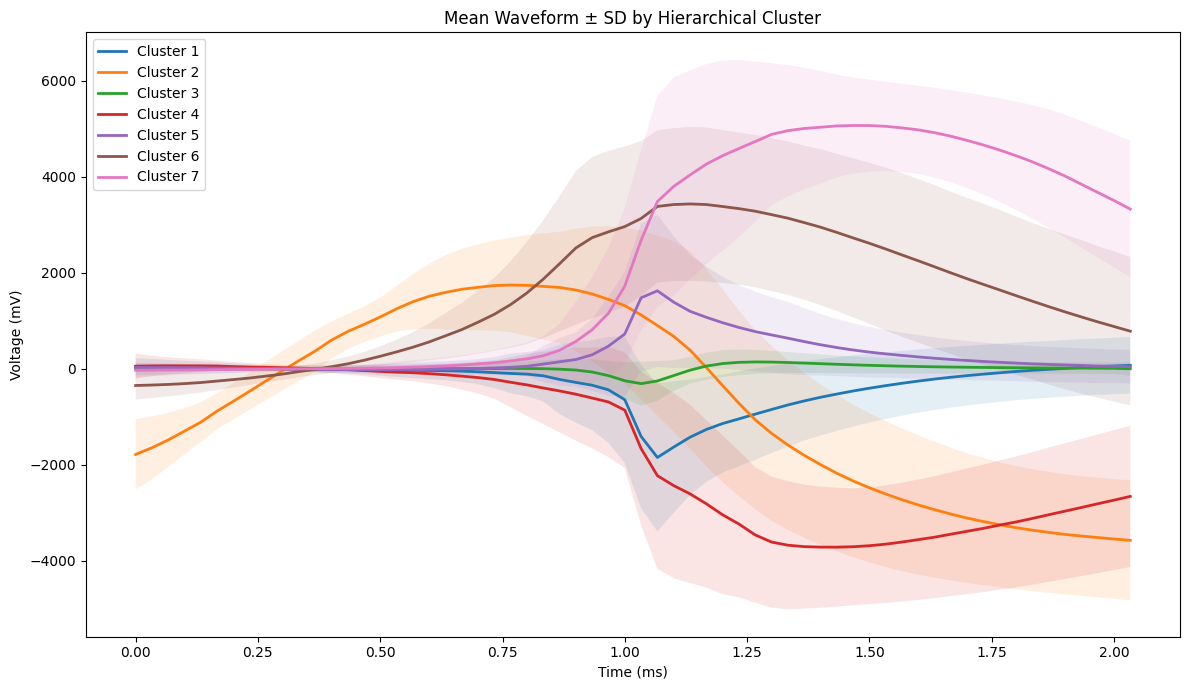

In [14]:
# ==========================
# Helper: mean waveform ± SD by cluster
# ==========================

def plot_mean_waveforms(
    waveform_df,
    cluster_col,
    method_name,
    waveform_columns,
    time_axis_ms
):
    clusters = sorted(waveform_df[cluster_col].dropna().unique())

    fig, ax = plt.subplots(figsize=(12, 7))

    for cluster in clusters:

        cluster_data = waveform_df.loc[
            waveform_df[cluster_col] == cluster,
            waveform_columns
        ]

        mean_waveform = cluster_data.mean(axis=0).values
        std_waveform = cluster_data.std(axis=0).values

        ax.plot(
            time_axis_ms,
            mean_waveform,
            linewidth=2,
            label=f"Cluster {cluster}"
        )

        ax.fill_between(
            time_axis_ms,
            mean_waveform - std_waveform,
            mean_waveform + std_waveform,
            alpha=0.12
        )

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Voltage (mV)")
    ax.set_title(f"Mean Waveform ± SD by {method_name} Cluster")
    ax.legend()

    plt.tight_layout()

    fig.savefig(
        os.path.join(
            output_dir,
            f"{method_name.lower()}_mean_waveforms_by_cluster.tiff"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_mean_waveforms(
    kmeans_waveforms,
    "kmeans_cluster",
    "KMeans",
    waveform_cols,
    time_ms
)

plot_mean_waveforms(
    hier_waveforms,
    "hierarchical_cluster",
    "Hierarchical",
    waveform_cols,
    time_ms
)


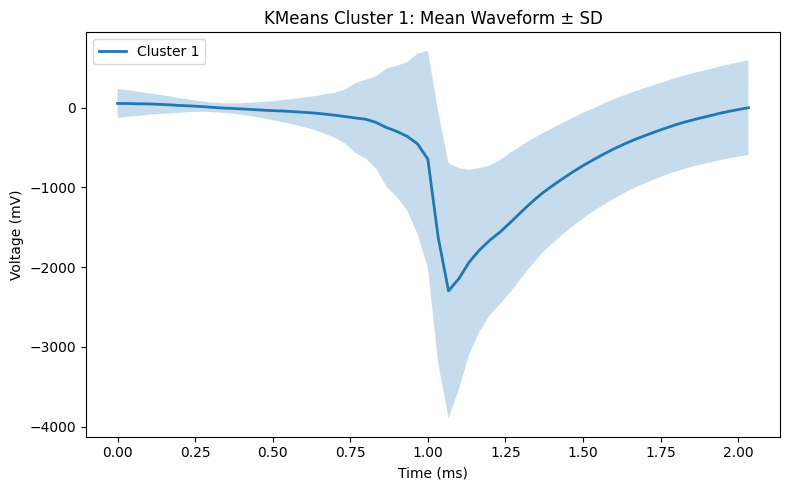

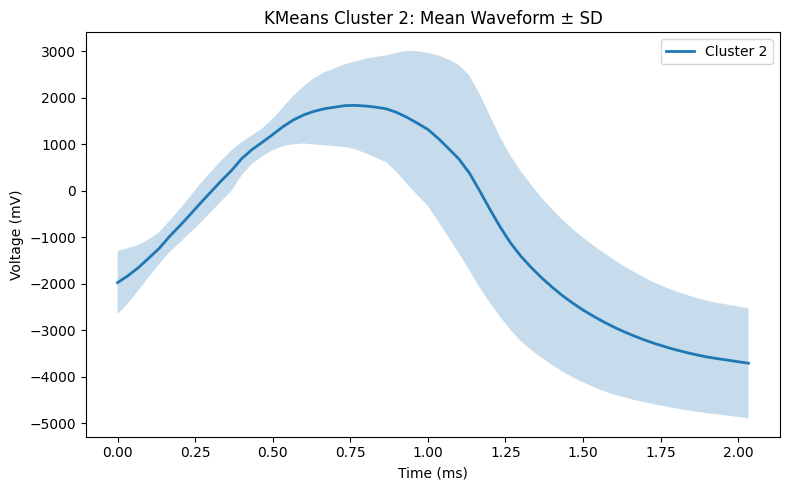

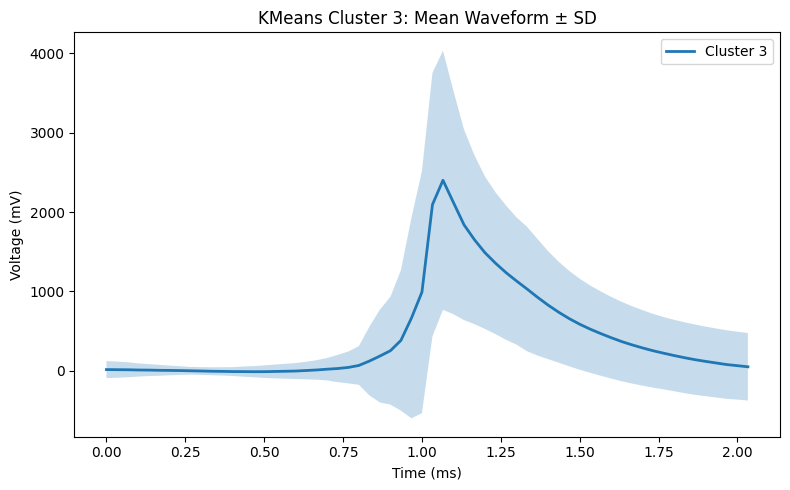

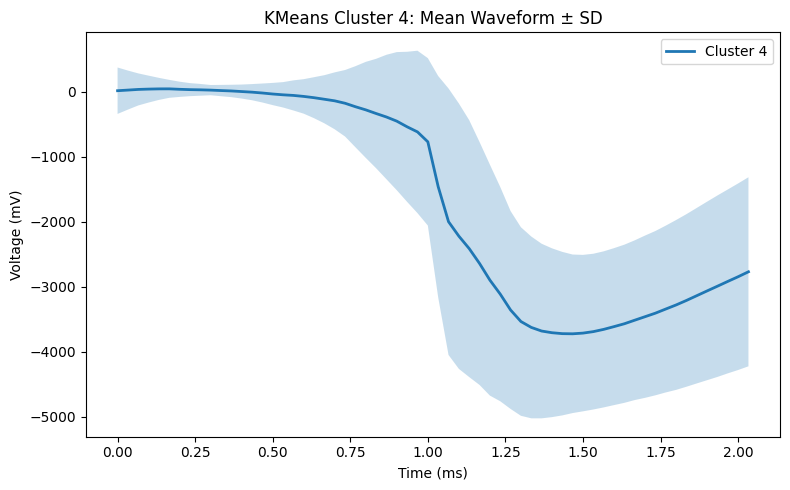

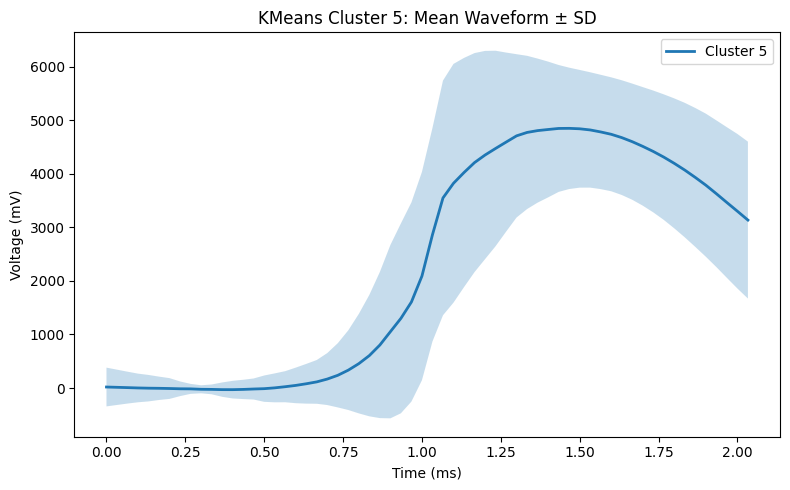

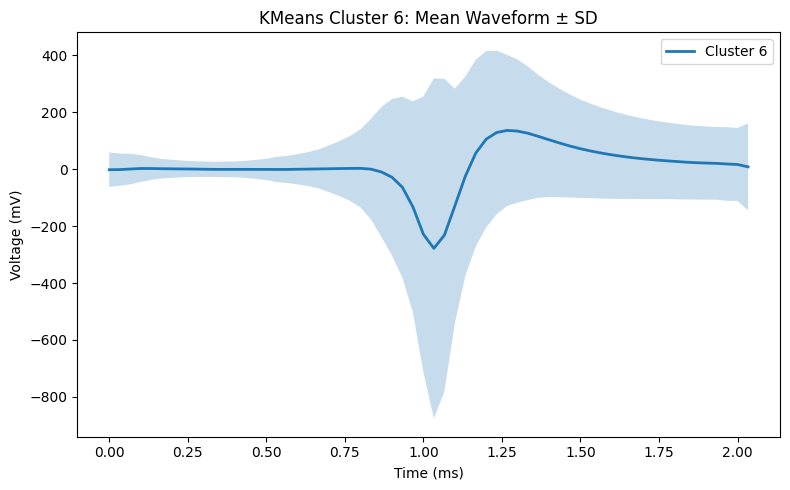

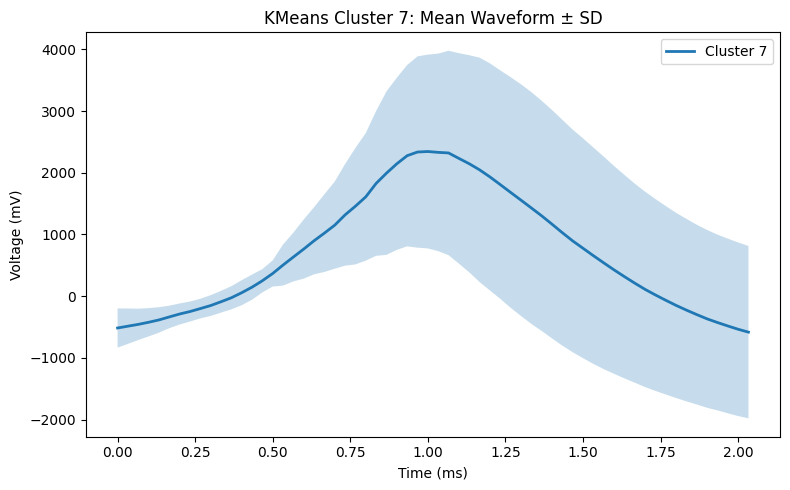

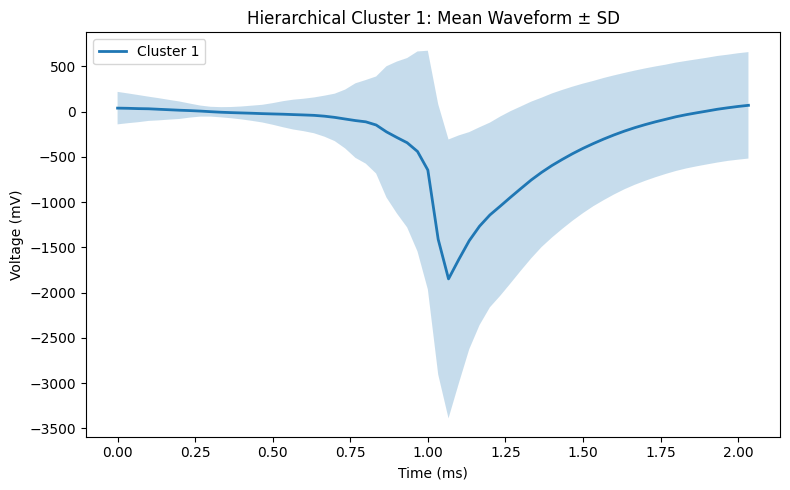

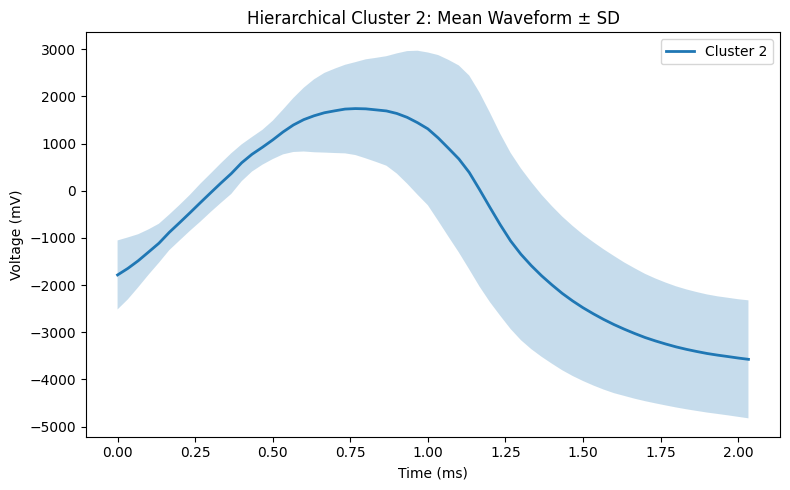

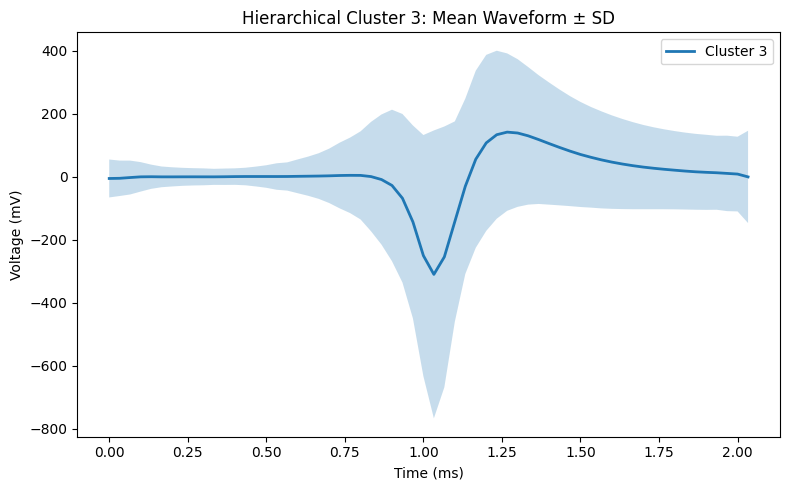

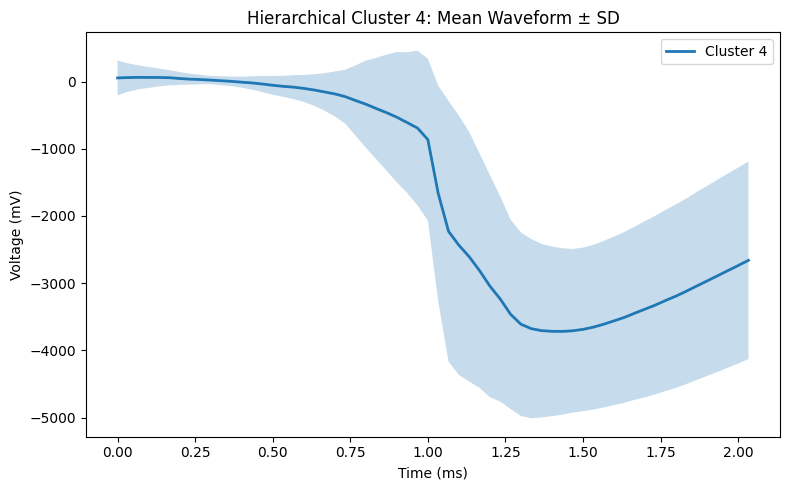

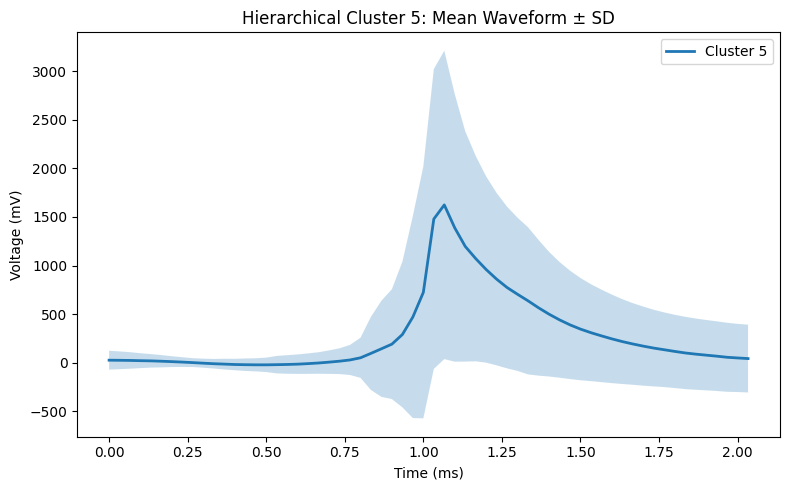

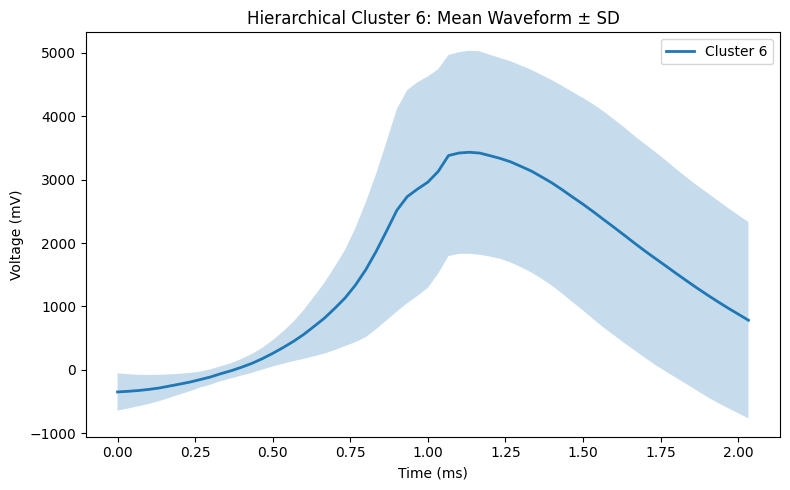

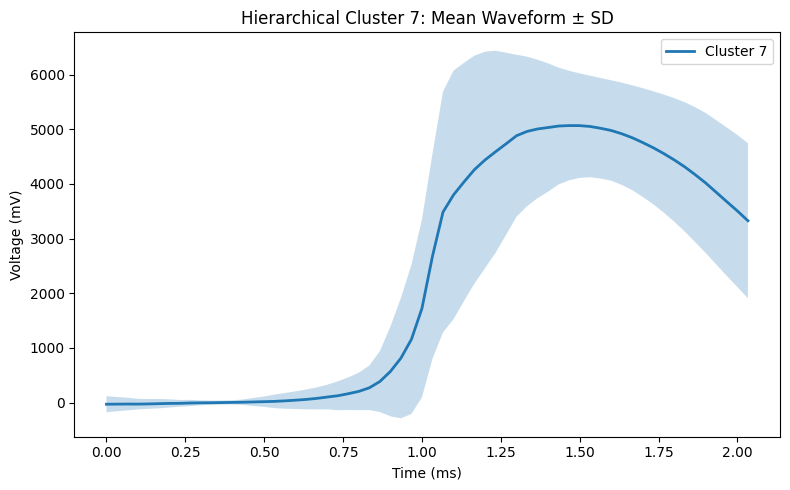

In [15]:
# ==========================
# Helper: separate mean waveform plots per cluster
# ==========================

def plot_individual_cluster_waveforms(
    waveform_df,
    cluster_col,
    method_name,
    waveform_columns,
    time_axis_ms
):
    clusters = sorted(waveform_df[cluster_col].dropna().unique())

    for cluster in clusters:

        cluster_data = waveform_df.loc[
            waveform_df[cluster_col] == cluster,
            waveform_columns
        ]

        mean_waveform = cluster_data.mean(axis=0).values
        std_waveform = cluster_data.std(axis=0).values

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(
            time_axis_ms,
            mean_waveform,
            linewidth=2,
            label=f"Cluster {cluster}"
        )

        ax.fill_between(
            time_axis_ms,
            mean_waveform - std_waveform,
            mean_waveform + std_waveform,
            alpha=0.25
        )

        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Voltage (mV)")
        ax.set_title(f"{method_name} Cluster {cluster}: Mean Waveform ± SD")
        ax.legend()

        plt.tight_layout()

        fig.savefig(
            os.path.join(
                output_dir,
                f"{method_name.lower()}_cluster_{cluster}_mean_waveform.tiff"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


plot_individual_cluster_waveforms(
    kmeans_waveforms,
    "kmeans_cluster",
    "KMeans",
    waveform_cols,
    time_ms
)

plot_individual_cluster_waveforms(
    hier_waveforms,
    "hierarchical_cluster",
    "Hierarchical",
    waveform_cols,
    time_ms
)


## Compare cluster labels and feature profiles across methods

The cluster numbers from KMeans and hierarchical clustering are not directly interchangeable. The next table identifies which hierarchical cluster most overlaps with each KMeans cluster.


In [18]:
# ==========================
# Best-overlap mapping between KMeans and hierarchical clusters
# ==========================

best_overlap = []

for kmeans_cluster in agreement_table.index:

    row = agreement_table.loc[kmeans_cluster]

    best_hier_cluster = row.idxmax()
    overlap_count = row.max()
    kmeans_total = row.sum()

    best_overlap.append({
        "kmeans_cluster": kmeans_cluster,
        "best_matching_hierarchical_cluster": best_hier_cluster,
        "overlap_count": overlap_count,
        "kmeans_cluster_total": kmeans_total,
        "overlap_fraction": overlap_count / kmeans_total
    })

best_overlap_df = pd.DataFrame(best_overlap)

display(best_overlap_df)

best_overlap_df.to_csv(
    os.path.join(output_dir, "best_cluster_overlap_mapping.csv"),
    index=False
)


,kmeans_cluster,best_matching_hierarchical_cluster,overlap_count,kmeans_cluster_total,overlap_fraction
0,1,1,974,1056,0.922348
1,2,2,73,73,1.000000
2,3,5,1499,1566,0.957216
3,4,4,171,193,0.886010
4,5,7,126,164,0.768293
5,6,3,21640,23711,0.912657
6,7,6,54,99,0.545455


In [19]:
# ==========================
# Export sorted enriched feature tables
# ==========================

kmeans_features_sorted = cluster_features.sort_values(
    ["kmeans_cluster", "original_row"]
)

hier_features_sorted = cluster_features.sort_values(
    ["hierarchical_cluster", "original_row"]
)

kmeans_features_sorted.to_csv(
    os.path.join(output_dir, "features_sorted_by_kmeans_cluster.csv"),
    index=False
)

hier_features_sorted.to_csv(
    os.path.join(output_dir, "features_sorted_by_hierarchical_cluster.csv"),
    index=False
)

print("Exported:")
print(os.path.join(output_dir, "features_sorted_by_kmeans_cluster.csv"))
print(os.path.join(output_dir, "features_sorted_by_hierarchical_cluster.csv"))


Exported:
../outputs/cluster_characterization/features_sorted_by_kmeans_cluster.csv
../outputs/cluster_characterization/features_sorted_by_hierarchical_cluster.csv


## Interpretation guide

Use these outputs to decide whether each cluster is meaningful:

1. **Cluster size:** very tiny clusters may be rare types or artifacts.
2. **Mean waveform shape:** meaningful clusters should show visibly different waveforms.
3. **Feature summaries:** clusters should differ in amplitude, timing, or waveform width.
4. **Boxplots:** check whether differences are strong or mostly overlapping.
5. **KMeans vs hierarchical agreement:** high agreement suggests robust groupings.
6. **Best-overlap mapping:** use this to compare cluster identities across methods even when numeric labels differ.
